In [0]:
import pandas as pd

path = "/Volumes/workspace/default/netflix_analysis/Neflix_cleaning_py.csv"
df = pd.read_csv(path)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4999 non-null   object
 1   type          4999 non-null   object
 2   title         4999 non-null   object
 3   director      3256 non-null   object
 4   cast          4534 non-null   object
 5   country       4371 non-null   object
 6   date_added    4999 non-null   object
 7   release_year  4999 non-null   int64 
 8   rating        4999 non-null   object
 9   duration      4999 non-null   object
 10  listed_in     4999 non-null   object
 11  description   4999 non-null   object
dtypes: int64(1), object(11)
memory usage: 468.8+ KB


 DATA PREPROCESSING FOR MODELING

In [0]:
def convert_duration(x):
    x = str(x)
    if "min" in x:
        return int(x.split()[0])
    if "Season" in x or "Seasons" in x:
        seasons = int(x.split()[0])
        return seasons * 240   # approx conversion
    return None

df["duration_min"] = df["duration"].apply(convert_duration)
df["duration_min"].fillna(df["duration_min"].median(), inplace=True)


/home/spark-b1080deb-eea8-43fd-a6fc-fa/.ipykernel/1618/command-7493538677552399-1549691392:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["duration_min"].fillna(df["duration_min"].median(), inplace=True)


Prepare genre list

In [0]:
df["genre_list"] = df["listed_in"].astype(str).apply(lambda x: [i.strip() for i in x.split(",")])


Encode rating

In [0]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["rating_enc"] = le.fit_transform(df["rating"].astype(str))


CLUSTERING ANALYSIS (K-Means)

In [0]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df["genre_list"])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)


In [0]:
import numpy as np
X_cluster = pd.concat([
    df[["duration_min", "rating_enc"]],
    genre_df
], axis=1)


In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)


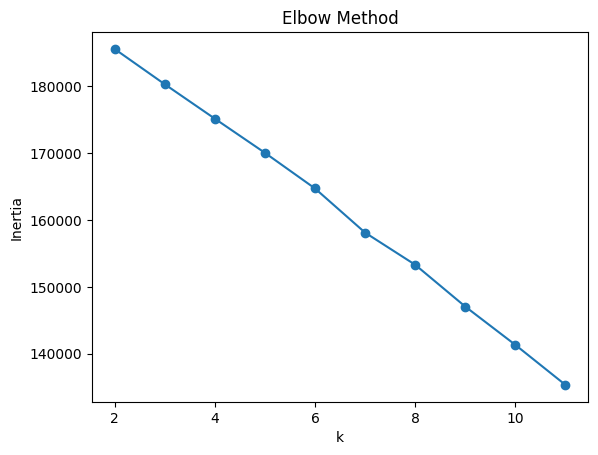

In [0]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

ssd = []
K = range(2, 12)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    ssd.append(km.inertia_)

plt.plot(K, ssd, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [0]:
km = KMeans(n_clusters=4, random_state=42)
df["cluster"] = km.fit_predict(X_pca)


In [0]:
df.groupby("cluster")[["duration_min", "rating_enc"]].mean()


,duration_min,rating_enc
cluster,,
0,103.179635,4.795332
1,388.506120,5.913784
2,384.000000,5.907692
3,128.176471,3.382353


In [0]:
cluster_genres = pd.concat([df["cluster"], genre_df], axis=1)
cluster_genres.groupby("cluster").sum().T.head(10)


cluster,0,1,2,3
Action & Adventure,419,0,0,13
Anime Features,52,0,0,2
Anime Series,0,138,1,0
British TV Shows,0,123,0,0
Children & Family Movies,354,0,0,2
Classic & Cult TV,0,11,0,0
Classic Movies,0,0,0,34
Comedies,958,0,0,6
Crime TV Shows,0,269,52,0
Cult Movies,18,0,0,4


CLASSIFICATION MODEL (Predict Movie vs TV Show)

In [0]:
df["type"] = df["type"].replace({"TV Show": 1, "Movie": 0})


/home/spark-b1080deb-eea8-43fd-a6fc-fa/.ipykernel/1618/command-7493538677552413-697130443:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["type"] = df["type"].replace({"TV Show": 1, "Movie": 0})


In [0]:
X = pd.concat([
    df[["duration_min", "rating_enc"]],
    genre_df
], axis=1)

y = df["type"]


In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [0]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


In [0]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       642
           1       1.00      1.00      1.00       358

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



KEY DRIVERS FOR CONTENT BY COUNTRY & GENRE

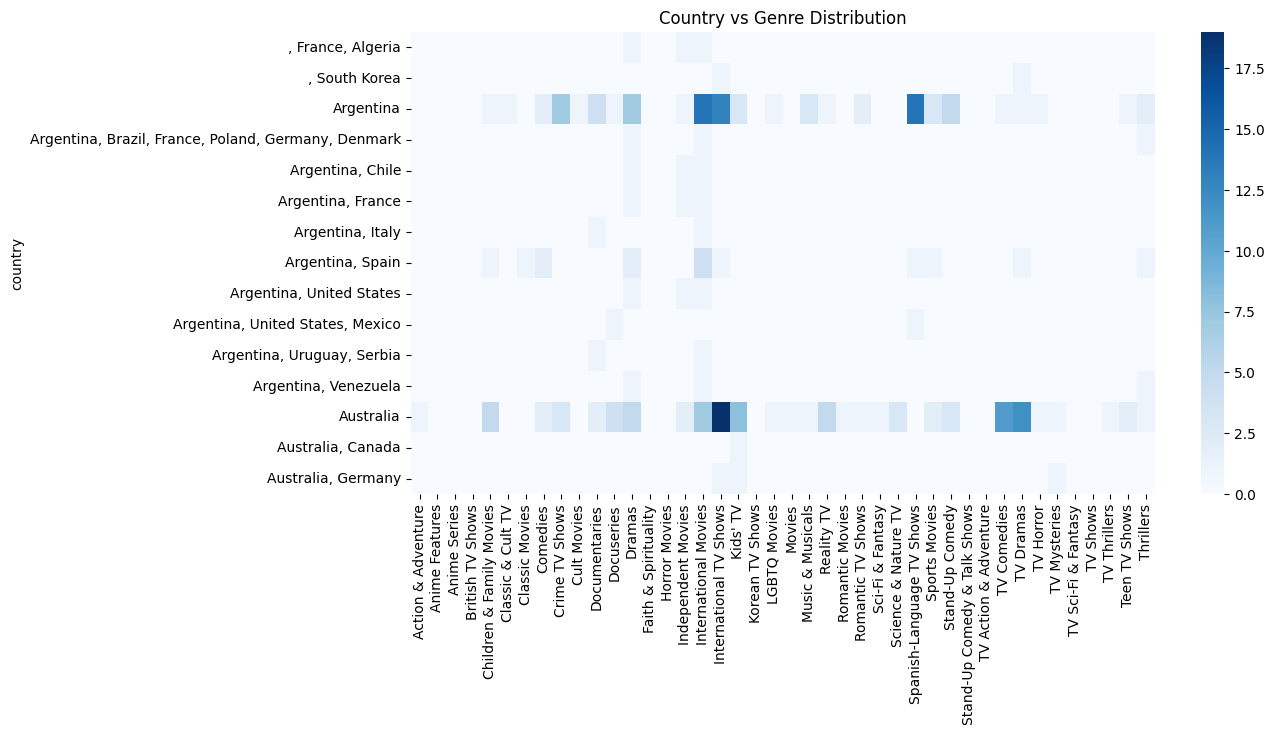

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

country_genre = pd.concat([df["country"], genre_df], axis=1)
country_genre = country_genre.groupby("country").sum()

plt.figure(figsize=(12, 6))
sns.heatmap(country_genre.head(15), cmap="Blues")
plt.title("Country vs Genre Distribution")
plt.show()


FEATURE IMPORTANCE ANALYSIS

In [0]:
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)


duration_min                0.471533
International TV Shows      0.147122
International Movies        0.076358
TV Dramas                   0.040855
TV Comedies                 0.040232
Dramas                      0.040180
Kids' TV                    0.033403
rating_enc                  0.023790
Comedies                    0.022470
Docuseries                  0.019183
Crime TV Shows              0.014943
Reality TV                  0.013949
Children & Family Movies    0.007648
Documentaries               0.006220
Stand-Up Comedy             0.006194
Romantic TV Shows           0.005171
Action & Adventure          0.004645
Anime Series                0.003993
TV Action & Adventure       0.002748
Romantic Movies             0.002526
dtype: float64

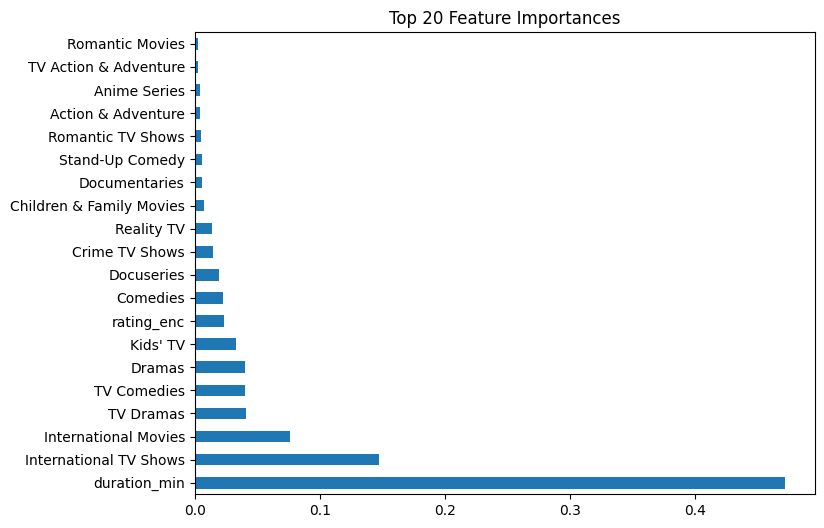

In [0]:
importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()
